In [9]:
#load libraries and snapshot
import numpy as np
import h5py as h5
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

libpath = "/beegfs/general/skoudmani/students/kasar/python/vortrace.libs"

os.environ["LD_LIBRARY_PATH"] = (
    libpath + ":" + os.environ.get("LD_LIBRARY_PATH", "")) #Adds the vortrace.libs directory to the Linux shared-library search path.
#This allows Python to find required .so files when importing vortrace

import sys
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #adds a custom directory to python's module search path
import vortrace as vt #vortrace performs Voronoi-based projections/interpolations for AREPO data.

# Load an Arepo snapshot
f = h5.File("/beegfs/general/kprofit/binary_tests/al_td_96/snapshot_000.hdf5", "r") #opens Arepo snapshot
pos = np.array(f["PartType0/Coordinates"]) #load gas cell positions
rho = np.array(f["PartType0/Density"]) #load gas desnities
mass = np.array(f["PartType0/Masses"]) #load gas cell masses
vol = mass / rho #calculate gas volume from mas and density
BoxSize = f["Parameters"].attrs["BoxSize"] #reads simulation box size from snapshot metadata
f.close()


Text(62.672222222222274, 0.5, 'y [pc]')

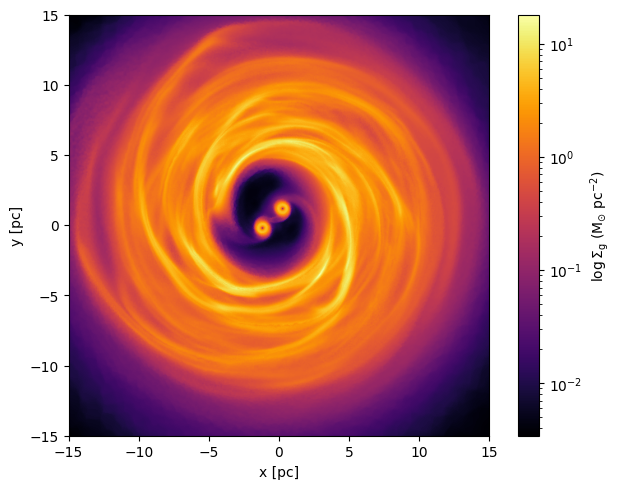

In [10]:
#Create projection and plot result
# Create a projection cloud
pc = vt.ProjectionCloud(
    pos, rho, vol=vol,
    boundbox=[0, BoxSize, 0, BoxSize, 0, BoxSize], #box = [xmin, xmax, ymin, ...]
) #constructs a voronoi projection object from position, density, volume and boxsixe

# Make a grid projection
L = 30.0 #projected image width (square region - length x width)
extent = [BoxSize / 2 - L / 2, BoxSize / 2 + L / 2] #defines x/y region to project
bounds = [0, BoxSize] #z projection depth
npix = 512 # resolution (num of pixels x num of pixels)

image = pc.grid_projection(extent, npix, bounds, center=None) # computes projected image

# Plot the result
fig, ax, im = vt.plot.plot_grid(image, extent=[-L / 2, L / 2, -L / 2, L / 2], label=r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$")

plt.tight_layout()
ax.set_xlabel("x [pc]")
ax.set_ylabel("y [pc]")
#fig.savefig("Voronoi_bin_projection.png", dpi=300, bbox_inches='tight')

In [11]:
import os
print(os.getcwd())

print(extent)

/beegfs/general/kprofit/analysis_scripts
[35.0, 65.0]
